540 final project: Cool things you can do with PyTao

Andrew Koren

What are the benefits of PyTao? You don't need to use Tao for data analysis.

1. let's scan through `rfcavity` and `lcavity` to learn how they really work. First off, the definitions

---
---

Lcavity:

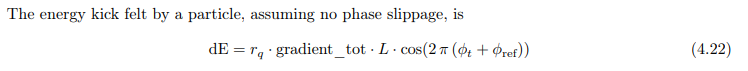

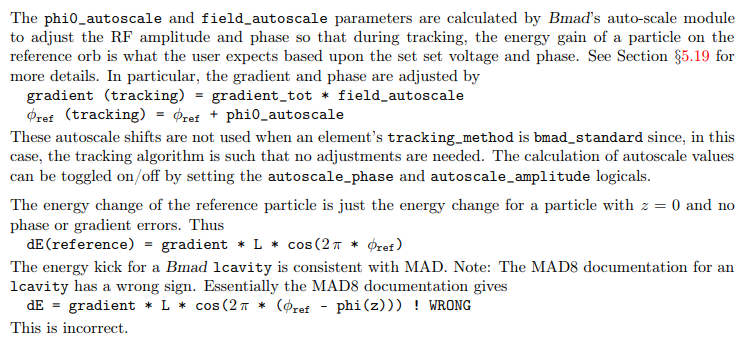

They also have an n_cell option. Also see section 18.8 (uses pillbox eqn).



26.14 Lcavity Tracking <br>
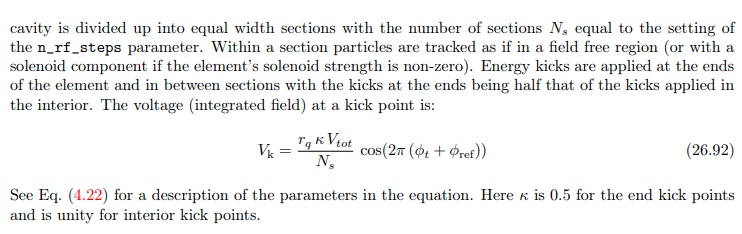
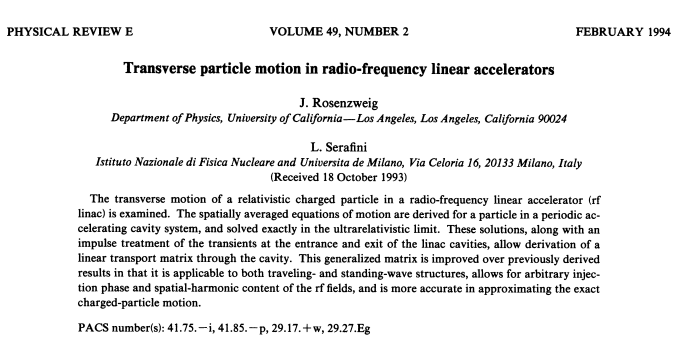
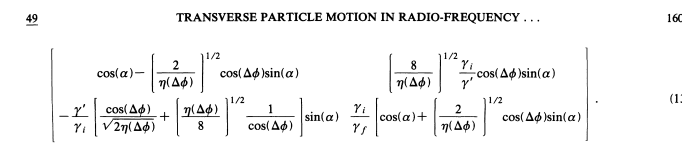

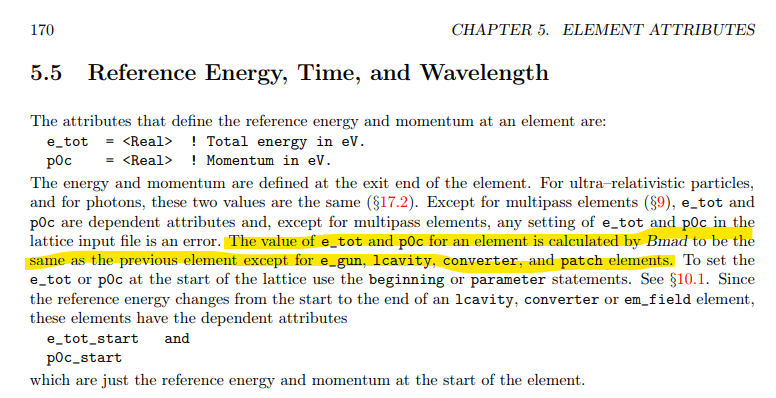

---
---

RF cavity:

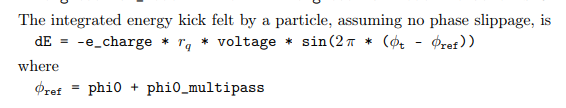

Note that the reference particle $\phi_t=$ by definition $\sin(0)=0$.

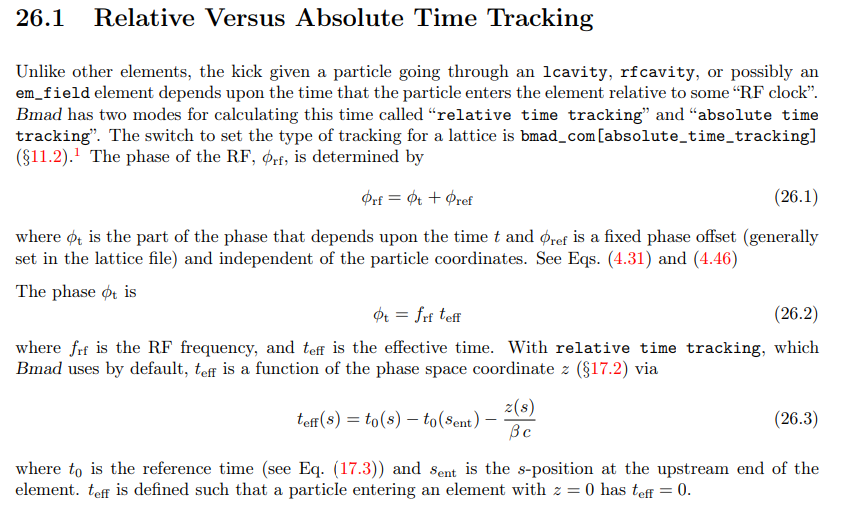
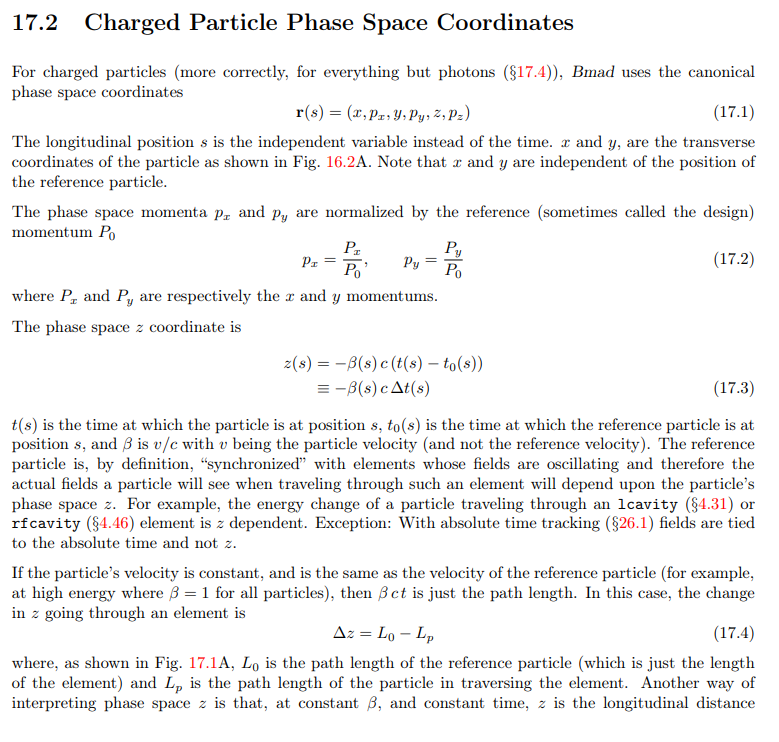

---
---

In our longitudinal dynamics project, we used

$$
\begin{cases}
    \phi_{n+1} = \phi_n + a_0 \Delta E_n
\\  \Delta E_{n+1} = \Delta E_n + a_1 \left(\sin \phi_{n+1} - \sin{\phi_s} \right)
\end{cases}
$$
where
$$
a_0 = { 2\pi h \eta \over \beta^2 E} \quad a_1 = eV
$$

Let's just try to connect this to the above to compare $\phi_s$ to $\phi_{\text{ref}}$

$$
\begin{align*}
\text{Bmad} :


\\
\text{Class}:


\end{align*}
$$

Optimized racetrack via 

```python
tao.cmd('write bmad output_racetrack.bmad')
```

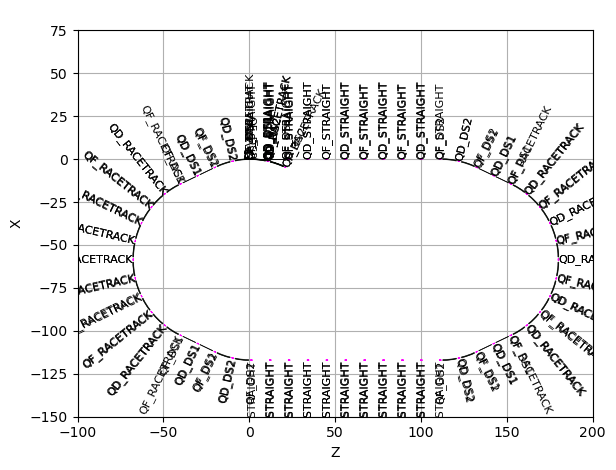

In [1]:
from pytao import SubprocessTao

init_file = "tao.init" 
lattice_file = "output_racetrack.bmad"
tao = SubprocessTao(init_file=init_file, lattice_file=lattice_file, plot="mpl")
tao.plot('floor', xlim = (-100, 200), ylim = (-150, 75))

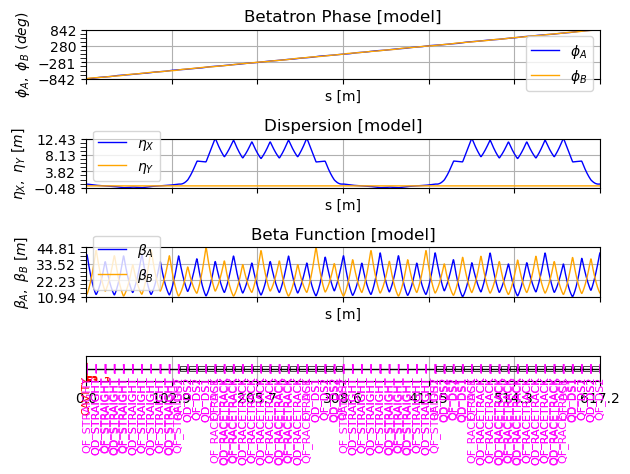

In [2]:
tao.cmd('set curve T::phase.g.* component = model') # 
tao.plot(['phase', 'dispersion', 'beta'])

In [3]:
tao.cmd('show lat')

['# Branch 0. Values shown are for the Downstream End of each Element (Girder elements shown at ref point):',
 '# Index  name         key                       s       l    beta   phi_a    eta   orbit    beta   phi_b    eta   orbit  Track',
 '#                                                               a   [2pi]      x  x [mm]       b   [2pi]      y  y [mm]  State',
 '      0  BEGINNING    Beginning_Ele         0.000     ---   40.45   0.000   0.48  -0.000   12.70   0.000   0.00   0.000  Alive',
 '      1  F3           Fork                  0.000   0.000   40.45   0.000   0.48  -0.000   12.70   0.000   0.00   0.000  Alive',
 '      2  F2_2         Fork                  0.000   0.000   40.45   0.000   0.48  -0.000   12.70   0.000   0.00   0.000  Alive',
 '      3  F2_1         Fork                  0.000   0.000   40.45   0.000   0.48  -0.000   12.70   0.000   0.00   0.000  Alive',
 '      4  F1           Fork                  0.000   0.000   40.45   0.000   0.48  -0.000   12.70   0.0

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np

columns = [
    "index", "x", "px", "y", "py", "z", "pz", "p0c",
    "s_position", "time", "spin_x", "spin_y", "spin_z",
    "state", "ix_ele", "location"
]

initial_df = pd.read_csv(
    "initial_beam.txt",
    comment="#",
    sep=r"\s+",
    names=columns,
    engine="python"
)

print(initial_df.head())


   index         x        px         y        py         z        pz  \
0      1 -0.002624 -0.000056  0.001382 -0.000053 -0.000026  0.000484   
1      2 -0.001769  0.000052  0.000677 -0.000032 -0.001401 -0.000632   
2      3  0.002143 -0.000031  0.000058  0.000087 -0.001658 -0.000325   
3      4 -0.001248  0.000027  0.000701  0.000065 -0.001805 -0.000567   
4      5 -0.000552 -0.000040  0.000007 -0.000008  0.000525  0.000302   

            p0c  s_position          time  spin_x  spin_y  spin_z  state  \
0  1.000000e+09         0.0  1.201097e-13     0.0     0.0     0.0  Alive   
1  1.000000e+09         0.0  6.409921e-12     0.0     0.0     0.0  Alive   
2  1.000000e+09         0.0  7.583303e-12     0.0     0.0     0.0  Alive   
3  1.000000e+09         0.0  8.257784e-12     0.0     0.0     0.0  Alive   
4  1.000000e+09         0.0 -2.400565e-12     0.0     0.0     0.0  Alive   

   ix_ele        location  
0       0  Downstream_End  
1       0  Downstream_End  
2       0  Downstream_End 

<Axes: xlabel='z', ylabel='pz'>

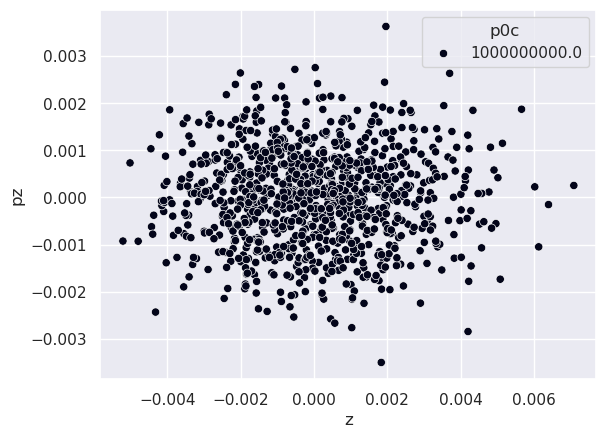

In [6]:
sns.set_theme()
sns.scatterplot(data=initial_df, x='z', y='pz', hue='p0c', palette='rocket')

/tmp/ipykernel_63728/540225467.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='z', y='pz', palette='rocket')


<Axes: xlabel='z', ylabel='pz'>

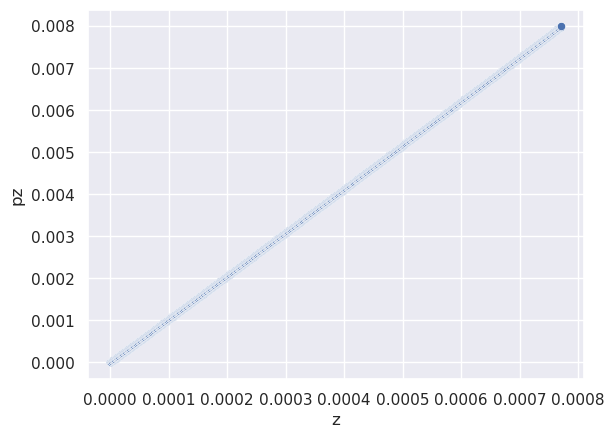

In [56]:
tao.cmd('pipe bunch1 1|model 1 pz')

[]

<Axes: xlabel='z', ylabel='pz'>

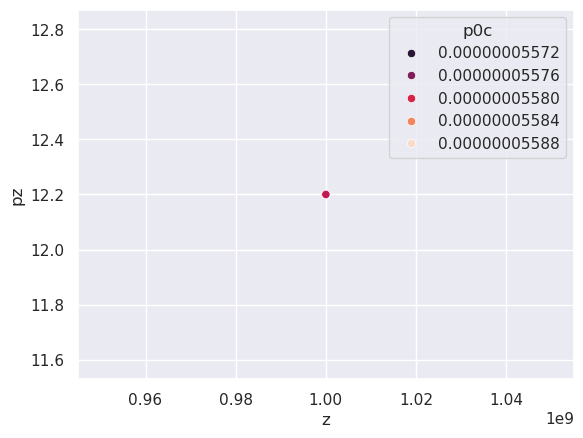

In [7]:
final_df = pd.read_csv(
    "turn_1.txt",
    comment="#",
    sep=r"\s+",
    names=columns,
    engine="python"
)
sns.scatterplot(data=final_df, x='z', y='pz', hue='p0c', palette='rocket')


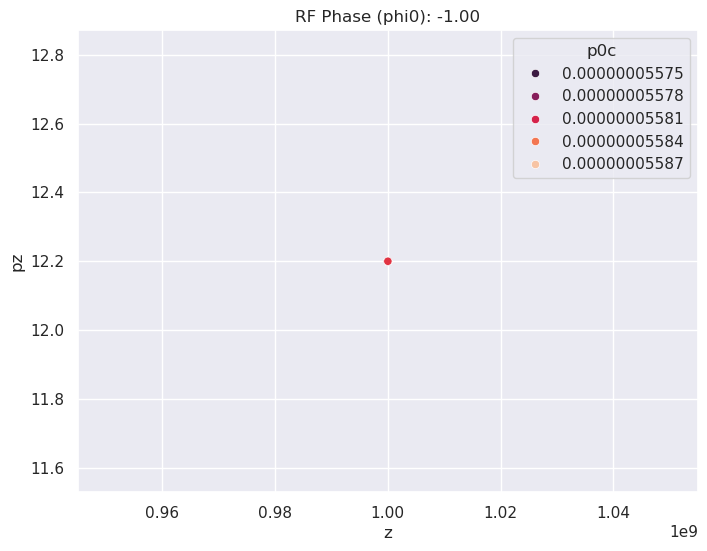

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def load_beam(filename, show = True, ax=None):
    beam_df =  pd.read_csv(
    f"{filename}.txt",
    comment="#",
    sep=r"\s+",
    names=columns)
    if show:
        sns.scatterplot(data=beam_df, x='z', y='pz', hue='p0c', palette='rocket', ax=ax)
    return beam_df


fig, ax = plt.subplots(figsize=(8, 6))
angles = np.linspace(-1, 1, 100)


def update(i):
    current_angle = angles[i]
    
    tao.cmd(f'set ele rfcav::* phi0 = {current_angle:.6f}')
    
    temp_filename = "temp_beam_frame"
    tao.cmd(f"write beam -ascii -at 10 {temp_filename}.txt")
    
    load_beam(temp_filename, show=True, ax=ax)
    
    ax.set_title(f"RF Phase (phi0): {current_angle:.2f}")

ani = FuncAnimation(fig, update, frames=len(angles), interval=100, repeat=True)

HTML(ani.to_html5_video())

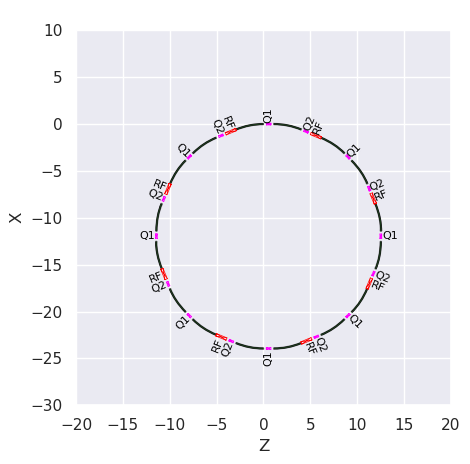

In [11]:
from pytao import SubprocessTao

init_file = "tao.init" 
lattice_file = "small_ring.bmad"
tao = SubprocessTao(init_file=init_file, lattice_file=lattice_file, plot="mpl")
tao.plot('floor', xlim = (-20, 20), ylim = (-30, 10))

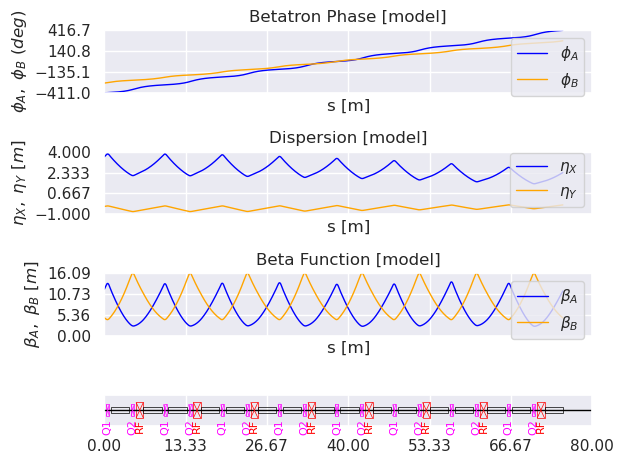

In [12]:
tao.cmd('set curve T::phase.g.* component = model') # 
tao.plot(['phase', 'dispersion', 'beta'])

In [13]:
tao.cmd('show lat')

['# Values shown are for the Downstream End of each Element (Girder elements shown at ref point):',
 '# Index  name      key                       s       l    beta   phi_a    eta   orbit    beta   phi_b    eta   orbit  Track',
 '#                                                            a   [2pi]      x  x [mm]       b   [2pi]      y  y [mm]  State',
 '      0  BEGINNING Beginning_Ele         0.000     ---   11.96   0.000   3.60   0.000    4.60   0.000  -0.37   0.000  Alive',
 '      1  D         Drift                 0.300   0.300   13.02   0.004   3.75   0.000    4.24   0.011  -0.34   0.000  Alive',
 '      2  Q1        Quadrupole            0.800   0.500   12.86   0.010   3.74   0.000    4.40   0.030  -0.35   0.000  Alive',
 '      3  D         Drift                 1.100   0.300   11.64   0.014   3.56   0.000    4.97   0.040  -0.39   0.000  Alive',
 '      4  B         SBend                 4.100   3.000    3.14   0.094   2.22   0.000   14.25   0.098  -0.74   0.000  Alive',
 '  

In [14]:
tao.cmd(f"write beam -ascii -at 0 initial_beam.txt")
tao.cmd(f"write beam -ascii -at 8 turn_1.txt")

['[INFO] tao_write_cmd:', '    Written: turn_1.txt']

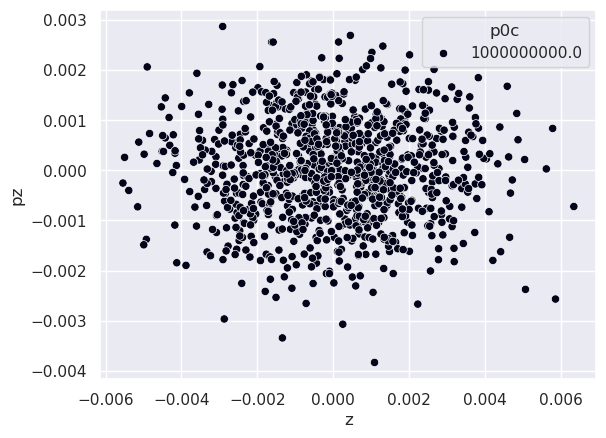

In [19]:
def load_beam(filename, show = True, ax=None):
    beam_df =  pd.read_csv(
    f"{filename}.txt",
    comment="#",
    sep=r"\s+",
    names=columns)
    if show:
        sns.scatterplot(data=beam_df, x='z', y='pz', hue='p0c', palette='rocket', ax=ax)
    return beam_df


load_beam('initial_beam');

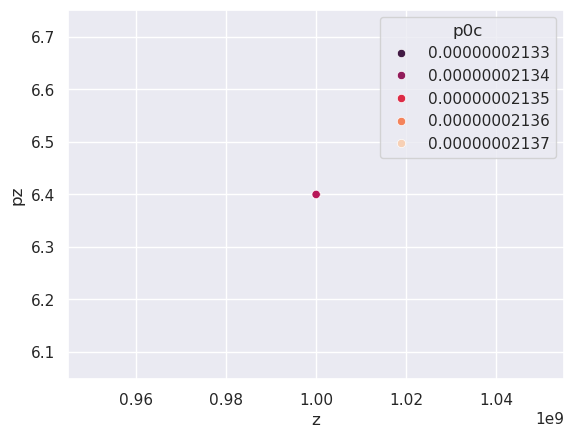

In [21]:
load_beam('turn_1');

In [92]:
def create_particle_file(z_arr, pz_arr):

    rows = "\n".join([
        f"{i+1:8d} {z_arr[i]:.6E}  {pz_arr[i]:.6E}  1.000000000000000E+10  0.000000000000000E+00  Alive       0  Upstream_End"
        for i in range(len(z_arr))
    ])

    # 2. The giant f-string template
    content = f"""# ix_bunch       =     1
# n_particle     =    {len(z_arr)}
# n_alive        =    {len(z_arr)}
# n_dead         =     0
# charge         =  1.0000000000000002E-12
# ix_branch      = 0
# direction      = 1
# time_dir       = 1
# species        = Proton              
#! index   z       pz                    p0c             s_position  state  ix_ele      location
{rows}"""

    # 3. Write to file
    with open('trace.dat', 'w') as f:
        f.write(content)

n_particles = 1000

z = np.random.normal(0,2e-3,size=n_particles)
pz= np.random.normal(0,1e-3,size=n_particles)


create_particle_file(z, pz)

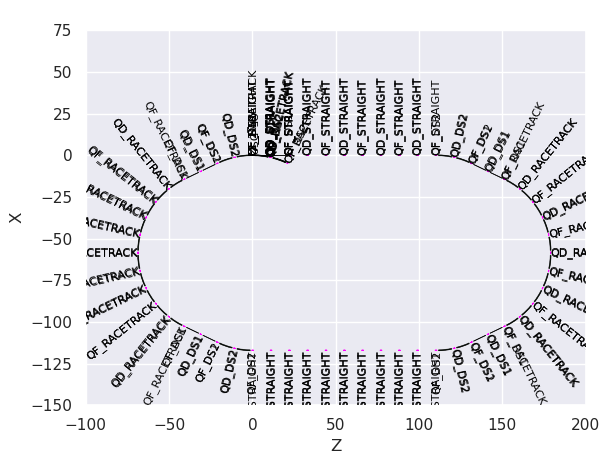

In [93]:
init_file = "tao.init" 
lattice_file = "output_racetrack.bmad"
tao = SubprocessTao(init_file=init_file, lattice_file=lattice_file, plot="mpl")
tao.plot('floor', xlim = (-100, 200), ylim = (-150, 75))

<Axes: xlabel='z', ylabel='pz'>

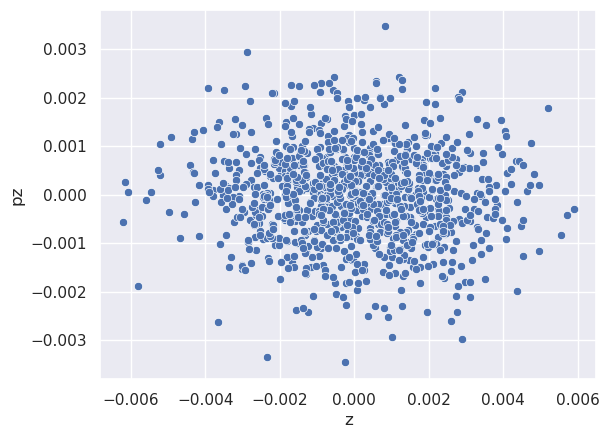

In [101]:
import io

data_list = tao.cmd('show particle -all -ele 10')
full_string = "\n".join(data_list[1:])

df = pd.read_csv(io.StringIO(full_string), sep=r'\s+')
sns.scatterplot(data=df, x='z', y='pz')